# Bank Customer Churn Prediction

**Goal:** Understand why customers leave the bank, engineer features that capture the
patterns we find, and build a model that flags customers likely to churn.

**Data:** 10,000 bank customers, 14 columns, target = `Exited` (1 = churned).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

## 1. Load & inspect the data

In [2]:
df = pd.read_csv('./data/Churn_Modelling.csv')
print(df.shape)
df.head()

(10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
# check missing values
print(df.isnull().sum())

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


In [4]:
print(df.dtypes)

RowNumber            int64
CustomerId           int64
Surname                str
CreditScore          int64
Geography              str
Gender                 str
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object


In [5]:
churn_count = df['Exited'].value_counts()
print(churn_count)

Exited
0    7963
1    2037
Name: count, dtype: int64


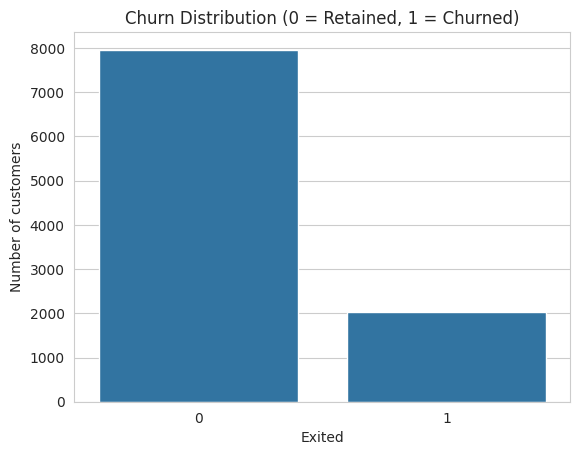

In [6]:
sns.countplot(x='Exited', data=df)
plt.title('Churn Distribution (0 = Retained, 1 = Churned)')
plt.xlabel('Exited')
plt.ylabel('Number of customers')
plt.show()

In [7]:
# 2037 people churned out of 10,000 customers
# which is 20.37% of customers

## 2. Exploratory data analysis

In [8]:
# first analyze the numeric features in EDA
numeric_columns = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
                   'HasCrCard', 'IsActiveMember', 'EstimatedSalary']

for col in numeric_columns:
    churned_avg = df[df['Exited'] == 1][col].mean()
    retained_avg = df[df['Exited'] == 0][col].mean()

    print(f'{col}: {churned_avg} | {retained_avg}')
    print()

CreditScore: 645.3514972999509 | 651.8531960316463

Age: 44.8379970544919 | 37.40838879819164

Tenure: 4.932744231713304 | 5.033278914981791

Balance: 91108.53933726068 | 72745.2967788522

NumOfProducts: 1.4752086401570939 | 1.5442672359663443

HasCrCard: 0.6990672557682867 | 0.7071455481602411

IsActiveMember: 0.36082474226804123 | 0.5545648624890117

EstimatedSalary: 101465.67753068237 | 99738.39177194524



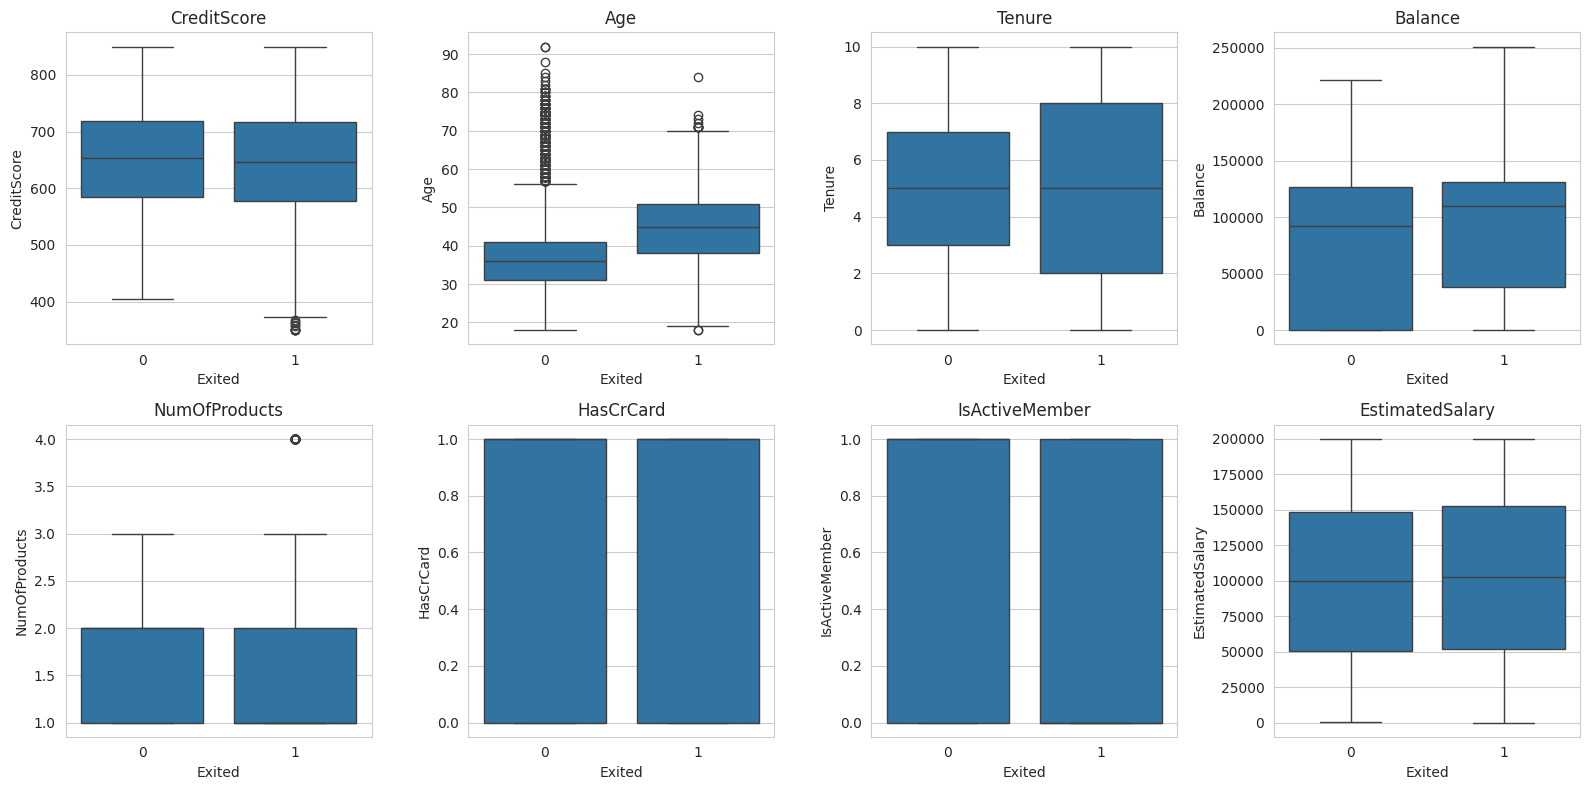

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col in zip(axes.flatten(), numeric_columns):
    sns.boxplot(x='Exited', y=col, data=df, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [10]:
# so, the chruned and retained avg tells us a lot
# for instance in age, the difference of both is more. and so it could be a factor of churn
# we can see balance could also be a factor
# credit score could be the next major factor after these two
# salary could be a factor too! but less chance, not much difference for those big values
# but more then credit card and salary, active member is a big factor 36% and 55%.
# the box plots confirm this visually: Age and Balance show the clearest separation
# between the two classes, the rest overlap heavily

In [11]:
# check for categorical data - Gender & Country
# first geography/country
# check how many countries are there
print(df['Geography'].unique())

<ArrowStringArray>
['France', 'Spain', 'Germany']
Length: 3, dtype: str


In [12]:
germany = df[df['Geography'] == 'Germany']
france = df[df['Geography'] == 'France']
spain = df[df['Geography'] == 'Spain']

churn_percent = (germany['Exited'] == 1).mean() * 100
retain_percent = (germany['Exited'] == 0).mean() * 100
print(f'Germany: {churn_percent.round(2)}% churned')

churn_percent1 = (france['Exited'] == 1).mean() * 100
retain_percent1 = (france['Exited'] == 0).mean() * 100
print(f'France: {churn_percent1.round(2)}% churned')

churn_percent2 = (spain['Exited'] == 1).mean() * 100
retain_percent2 = (spain['Exited'] == 0).mean() * 100
print(f'Spain: {churn_percent2.round(2)}% churned')

Germany: 32.44% churned
France: 16.15% churned
Spain: 16.67% churned


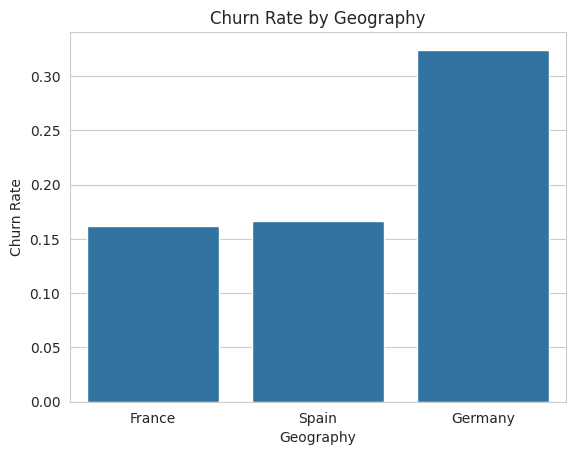

In [13]:
sns.barplot(x='Geography', y='Exited', data=df, errorbar=None)
plt.ylabel('Churn Rate')
plt.title('Churn Rate by Geography')
plt.show()

In [14]:
# now lets check for the gender

male = df[df['Gender'] == 'Male']
female = df[df['Gender'] == 'Female']

churn_percent = (male['Exited'] == 1).mean() * 100
retain_percent = (male['Exited'] == 0).mean() * 100
print(f'Male: {churn_percent.round(2)}% churned')

churn_percent1 = (female['Exited'] == 1).mean() * 100
retain_percent1 = (female['Exited'] == 0).mean() * 100
print(f'Female: {churn_percent1.round(2)}% churned')

Male: 16.46% churned
Female: 25.07% churned


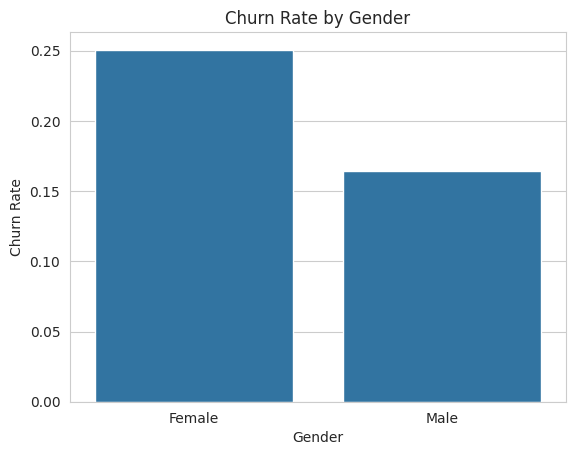

In [15]:
sns.barplot(x='Gender', y='Exited', data=df, errorbar=None)
plt.ylabel('Churn Rate')
plt.title('Churn Rate by Gender')
plt.show()

In [16]:
# and also female chruned more than male
# and germans churned more than france and spain

## 3. Feature engineering

In [17]:
# now, time for feature engineering.
# in this, we convert the categories into numbers for our convenience to analyze, not just for us, for the machine as well.

In [18]:
# so the first thing to do, remove the useless columns
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

In [19]:
df.columns.tolist()

['CreditScore',
 'Geography',
 'Gender',
 'Age',
 'Tenure',
 'Balance',
 'NumOfProducts',
 'HasCrCard',
 'IsActiveMember',
 'EstimatedSalary',
 'Exited']

In [20]:
# Gender is genuinely binary so a 0/1 map is fine
# Geography has 3 unrelated categories (France, Germany, Spain) - there's no natural order
# between them, so instead of LabelEncoder (which would imply Spain > Germany > France)
# we one-hot encode it. This matters for Logistic Regression, which would otherwise treat
# Geography as a single ordinal number; tree models don't care either way but it's still
# the correct way to represent an unordered category.

df['Gender'] = df['Gender'].map({'Female': 0, 'Male': 1})
df = pd.get_dummies(df, columns=['Geography'], drop_first=True, dtype=int)
df.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,0,0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0,1
2,502,0,42,8,159660.80,3,1,0,113931.57,1,0,0
3,699,0,39,1,0.00,2,0,0,93826.63,0,0,0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0,1


In [21]:
# ok, so now we go for detailed analysis and for this we might domain knowledge to some extent
# so i observed that there are persons with zero balance

In [22]:
zero_balance = (df['Balance'] == 0).sum()
total = len(df)
zero_percent = (zero_balance / total) * 100

print(f"Total customers: {total}")
print(f"Customers with zero balance: {zero_balance} which is ({zero_percent:.2f}%)")
print(f"Customers with balance > 0: {total - zero_balance}")

Total customers: 10000
Customers with zero balance: 3617 which is (36.17%)
Customers with balance > 0: 6383


In [23]:
# Now check if zero balance customers churn more?
zero_bal_churn = df[df['Balance'] == 0]['Exited'].mean() * 100
nonzero_bal_churn = df[df['Balance'] > 0]['Exited'].mean() * 100

print(f"customers with zero balance churned {zero_bal_churn.round(2)}")
print(f"customers with no zero balance churned {nonzero_bal_churn.round(2)}")

customers with zero balance churned 13.82
customers with no zero balance churned 24.08


In [24]:
# actually that assumption does not look valid
# so i think checking if zero balance and active, zero balance inactive and vice versa cases churn more

groups = {
    'Zero Balance & Inactive' : df[(df['Balance'] == 0) & (df['IsActiveMember'] == 0)],
    'Zero Balance & Active'   : df[(df['Balance'] == 0) & (df['IsActiveMember'] == 1)],
    'Has Balance & Inactive'  : df[(df['Balance'] > 0)  & (df['IsActiveMember'] == 0)],
    'Has Balance & Active'    : df[(df['Balance'] > 0)  & (df['IsActiveMember'] == 1)],
}

for group_name, group_df in groups.items():
    count = len(group_df)
    churn_rate = group_df['Exited'].mean() * 100
    print(f"{group_name} | {count} | {churn_rate.round(2)}%")

Zero Balance & Inactive | 1744 | 18.35%
Zero Balance & Active | 1873 | 9.61%
Has Balance & Inactive | 3105 | 31.63%
Has Balance & Active | 3278 | 16.93%


In [25]:
# so, wonder! people with balance and inactive churning more!!
# oh, wait, we kinda had that asssumption no?

In [26]:
# yes, so we found that people who churned has more avg balance
# so, we jsut proved it is right! not a new thing we found! but yeah good to think like that.
# and i can see that checking zero balance churning is a waste of time!

In [27]:
# so we can create our first feature, disengaged flag! => balance & inactive together
df['DisengagedFlag'] = (
    (df['Balance'] > 0) &
    (df['IsActiveMember'] == 0)
).astype(int)

count = df['DisengagedFlag'].sum()
churn_rate = df[df['DisengagedFlag'] == 1]['Exited'].mean() * 100
print(f"{churn_rate.round(2)}% churn")

31.63% churn


In [28]:
# great! we checked if we created it right
df.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,DisengagedFlag
0,619,0,42,2,0.00,1,1,1,101348.88,1,0,0,0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0,1,0
2,502,0,42,8,159660.80,3,1,0,113931.57,1,0,0,1
3,699,0,39,1,0.00,2,0,0,93826.63,0,0,0,0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0,1,0


In [29]:
# now i think of things i had learnt in class
# so my teacher always talks in ditribution. like overall distribution where does less than 0 and more then 0 lie in this distribution all this!
# so, i remember she always says check correlation
# so i think we need to check correlation also. lets see.

In [30]:
# but hey! i noticed something.
# there's another field we did not check. no.of products!
# let me check what it has to do with churning
churned_avg = df[df['Exited'] == 1]['NumOfProducts'].mean()
retained_avg = df[df['Exited'] == 0]['NumOfProducts'].mean()

print(f"Churned customers avg products:  {churned_avg.round(2)}")
print(f"Retained customers avg products: {retained_avg.round(2)}")

Churned customers avg products:  1.48
Retained customers avg products: 1.54


In [31]:
# ok, that doesn't tell us anything much
# lets try per number. like, customers with 1 product, how many people churned and all

product_churn = df.groupby('NumOfProducts')['Exited'].agg(['mean', 'count'])
product_churn['mean'] = product_churn['mean'] * 100
product_churn.columns = ['Churn Rate %', 'Customer Count']
print(product_churn)

               Churn Rate %  Customer Count
NumOfProducts                              
1                 27.714398            5084
2                  7.581699            4590
3                 82.706767             266
4                100.000000              60


In [32]:
# wow! there it is! customers with 1 and 3 products are churning and that too above average
# people with 3 prodcuts are quite large than in distribution
# but thats absurd! churned and retained average does not differ much
# but they are small values, lets check the max value of the no.of products
print(df['NumOfProducts'].max())

4


In [33]:
# well, maximum 4 products, how much would they vary anyway.
# so this might not say much about the chrun. lets go ahead

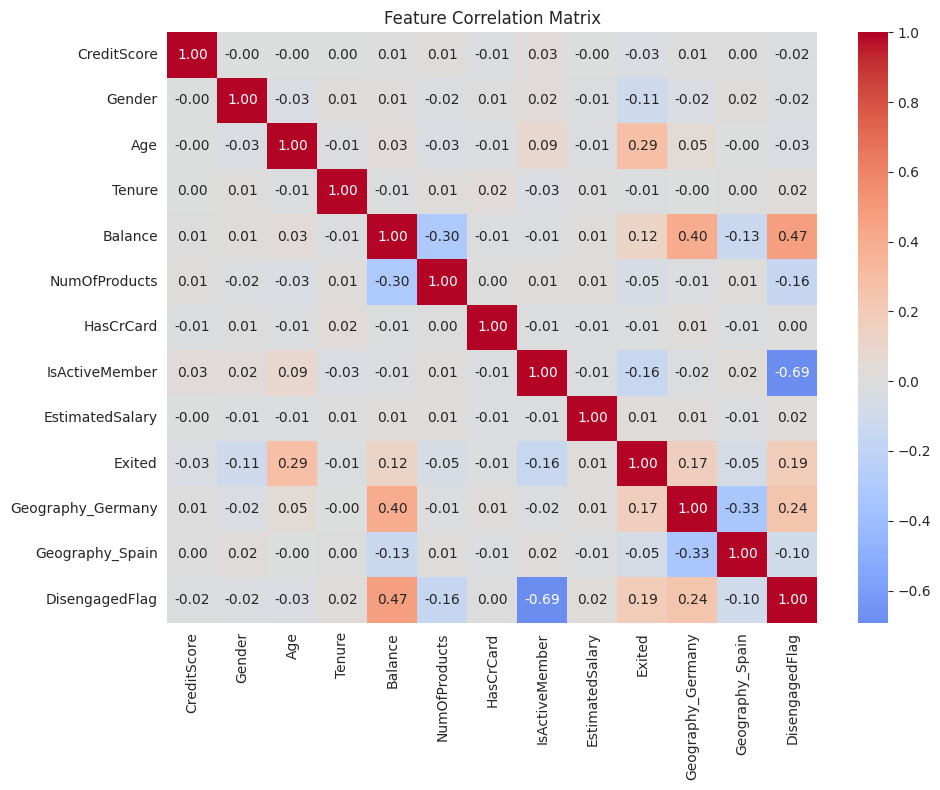

In [34]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [35]:
# Combining NumOfProducts with other columns vs Churn

# 1. NumOfProducts + IsActiveMember
print("NumOfProducts + Activity vs Churn:")

products_activity = df.groupby(['NumOfProducts', 'IsActiveMember'])['Exited'].agg(['mean', 'count'])
products_activity['mean'] = (products_activity['mean'] * 100).round(2)
products_activity.columns = ['Churn Rate %', 'Count']
print(products_activity)

NumOfProducts + Activity vs Churn:
                              Churn Rate %  Count
NumOfProducts IsActiveMember                     
1             0                      36.65   2521
              1                      18.92   2563
2             0                       9.89   2144
              1                       5.56   2446
3             0                      88.24    153
              1                      75.22    113
4             0                     100.00     31
              1                     100.00     29


In [36]:
target_group = df[(df['NumOfProducts'] == 1) & (df['IsActiveMember'] == 0)]
total = len(target_group)
churn_rate = target_group['Exited'].mean() * 100

print(f"Customers with 1 product + Inactive: {total}")
print(f"Their churn rate: {churn_rate:.2f}%")
print(f"Overall average churn: 20.37%")
print(f"Difference: +{churn_rate - 20.37:.2f}% above average")

Customers with 1 product + Inactive: 2521
Their churn rate: 36.65%
Overall average churn: 20.37%
Difference: +16.28% above average


In [37]:
df['AtRiskCustomer'] = (
    (df['NumOfProducts'] == 1) &
    (df['IsActiveMember'] == 0)
).astype(int)

# Verify
count = df['AtRiskCustomer'].sum()
churn_rate = df[df['AtRiskCustomer'] == 1]['Exited'].mean() * 100

print(f"At risk customers: {count}")
print(f"Their churn rate: {churn_rate:.2f}%")

At risk customers: 2521
Their churn rate: 36.65%


In [38]:
# Investigate Age properly

# Basic distribution
print(f"Minimum age: {df['Age'].min()}")
print(f"Maximum age: {df['Age'].max()}")
print(f"Overall average age: {df['Age'].mean():.2f}")

# Age groups
df['TempAgeGroup'] = pd.cut(df['Age'],
                             bins=[0, 30, 40, 50, 60, 100],
                             labels=['<30', '30-40', '40-50', '50-60', '60+'])

age_churn = df.groupby('TempAgeGroup')['Exited'].agg(['mean', 'count'])
age_churn['mean'] = (age_churn['mean'] * 100).round(2)
age_churn.columns = ['Churn Rate %', 'Count']
print(age_churn)

Minimum age: 18
Maximum age: 92
Overall average age: 38.92
              Churn Rate %  Count
TempAgeGroup                     
<30                   7.52   1968
30-40                12.09   4451
40-50                33.97   2320
50-60                56.21    797
60+                  24.78    464


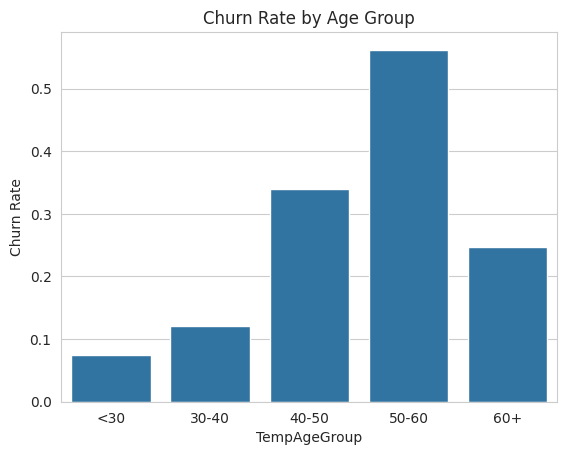

In [39]:
sns.barplot(x='TempAgeGroup', y='Exited', data=df, errorbar=None,
            order=['<30', '30-40', '40-50', '50-60', '60+'])
plt.ylabel('Churn Rate')
plt.title('Churn Rate by Age Group')
plt.show()

# Drop temp column
df = df.drop('TempAgeGroup', axis=1)

In [40]:
# ok, right now, its confusing. not kind of, but really confusing.
# like, what do we conclude! this is really interesting than i thought it would be

In [41]:
# so actually, i did not see it right. we can see, for age 50-60 -> 56.21% of 797. which is 447
#                                                  for age 40-50 -> 33.97% of 2320 which is 778 <- this is a little high in number

In [42]:
# Combine 40-50 and 50-60 and check with that

age_4060 = df[(df['Age'] >= 40) & (df['Age'] < 60)]

total = len(age_4060)
churned = (age_4060['Exited'] == 1).sum()
churn_rate = (churned / total) * 100

print(f"Customers aged 40-60: {total}")
print(f"Actual churners: {churned}")
print(f"Churn rate: {churn_rate:.2f}%")
print(f"Overall average: 20.37%")
print(f"Difference: +{churn_rate - 20.37:.2f}% above average")

Customers aged 40-60: 3487
Actual churners: 1293
Churn rate: 37.08%
Overall average: 20.37%
Difference: +16.71% above average


In [43]:
# that is interesting but lets check with the inactive too. maybe combining both might say something

In [44]:
# Age 40-60 + Inactive combined
group = df[
    (df['Age'] >= 40) &
    (df['Age'] < 60) &
    (df['IsActiveMember'] == 0)
]

total = len(group)
churn_rate = group['Exited'].mean() * 100
print(f"Customers: {total}")
print(f"Churn rate: {churn_rate:.2f}%")

Customers: 1769
Churn rate: 47.09%


In [45]:
# lets check for 40-50 and 50-60 separately and then compare which one to choose for the feature

In [46]:
# 40-50 + Inactive
group1 = df[
    (df['Age'] >= 40) &
    (df['Age'] < 50) &
    (df['IsActiveMember'] == 0)
]
print(f"40-50 + Inactive: {len(group1)} customers, {group1['Exited'].mean()*100:.2f}% churn")

# 50-60 + Inactive
group2 = df[
    (df['Age'] >= 50) &
    (df['Age'] < 60) &
    (df['IsActiveMember'] == 0)
]
print(f"50-60 + Inactive: {len(group2)} customers, {group2['Exited'].mean()*100:.2f}% churn")

40-50 + Inactive: 1396 customers, 37.97% churn
50-60 + Inactive: 373 customers, 81.23% churn


In [47]:
# so based on different numbering reasons we can consider that 40-60 is a good number and making it a feature
df['AgeActivityRisk'] = (
    (df['Age'] >= 40) &
    (df['Age'] < 60) &
    (df['IsActiveMember'] == 0)
).astype(int)

count = df['AgeActivityRisk'].sum()
churn_rate = df[df['AgeActivityRisk'] == 1]['Exited'].mean() * 100
print(f"Customers flagged: {count}")
print(f"Churn rate: {churn_rate:.2f}%")

Customers flagged: 1769
Churn rate: 47.09%


In [48]:
# now we could actually go on combining different columns and checking the churn rate but that get us nowhere.
# lets start training it
# i say we need to consider at least 3 models to train and then compare their performance
# we cannot just compare accuracy, we need to consider others too! like, f1 score and something

## 4. Train/test split & baseline models

In [49]:
# first thing's first
# splitting the data into train and test and wait
# before that, this checking
# Separate features (X) and target (y)

X = df.drop('Exited', axis=1)
y = df['Exited']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nFeatures machine will use:")
print(X.columns.tolist())
print(f"\nTarget (what we're predicting):")
print(y.value_counts())

X shape: (10000, 14)
y shape: (10000,)

Features machine will use:
['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_Germany', 'Geography_Spain', 'DisengagedFlag', 'AtRiskCustomer', 'AgeActivityRisk']

Target (what we're predicting):
Exited
0    7963
1    2037
Name: count, dtype: int64


In [50]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% for testing
    random_state=42,    # so we get same results every time
    stratify=y          # maintains 20.37% churn ratio in both sets
)

print(f"Training set: {X_train.shape[0]} customers")
print(f"Testing set:  {X_test.shape[0]} customers")
print(f"\nChurn ratio in training set: {y_train.mean()*100:.2f}%")
print(f"Churn ratio in testing set:  {y_test.mean()*100:.2f}%")

Training set: 8000 customers
Testing set:  2000 customers

Churn ratio in training set: 20.38%
Churn ratio in testing set:  20.35%


In [51]:
# now scaling the data
# we have variety of data like age, balance, tenure with different numbers

In [52]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit on training data and transform
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set scaled: {X_train_scaled.shape}")
print(f"Testing set scaled:  {X_test_scaled.shape}")

Training set scaled: (8000, 14)
Testing set scaled:  (2000, 14)


In [53]:
# now training! finally.
# choosing the models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Define 3 models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost'            : XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
}

In [54]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

results = {}

for model_name, model in models.items():

    # Logistic Regression uses scaled data
    # Tree based models (RF, XGBoost) don't need scaling
    if model_name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Calculate metrics
    results[model_name] = {
        'Accuracy' : accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall'   : recall_score(y_test, y_pred),
        'F1'       : f1_score(y_test, y_pred),
        'ROC-AUC'  : roc_auc_score(y_test, y_pred_proba)
    }

In [55]:
results_df = pd.DataFrame(results).T
print(results_df.round(4))

                     Accuracy  Precision  Recall      F1  ROC-AUC
Logistic Regression    0.8300     0.6791  0.3120  0.4276   0.7939
Random Forest          0.8590     0.7593  0.4496  0.5648   0.8456
XGBoost                0.8515     0.7007  0.4717  0.5639   0.8362


In [56]:
# i think we clearly have a winner in most of the metrics - Random forest. Congratualtions. But eveyrthing is very close!
# all the values are too close and in F1 - RF is not better than XGBoost. We need to validate the result

In [57]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for model_name, model in models.items():

    if model_name == 'Logistic Regression':
        scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='f1')
    else:
        scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1')

    print(f"{model_name}")
    print(f"  folds: {[round(s, 4) for s in scores]}")
    print(f"  mean F1: {scores.mean():.4f}, std: {scores.std():.4f}")

Logistic Regression
  folds: [np.float64(0.4093), np.float64(0.46), np.float64(0.4668), np.float64(0.4151), np.float64(0.4167)]
  mean F1: 0.4336, std: 0.0246


Random Forest
  folds: [np.float64(0.584), np.float64(0.597), np.float64(0.6026), np.float64(0.5282), np.float64(0.5405)]
  mean F1: 0.5705, std: 0.0303


XGBoost
  folds: [np.float64(0.576), np.float64(0.6018), np.float64(0.6195), np.float64(0.5292), np.float64(0.5148)]
  mean F1: 0.5683, std: 0.0405


In [58]:
# so we used stratified k fold and cross validated the model and found the mean and strandard deviations
# to see how variant the models are across the groups of data
# and we can see that XGBoost is slightly less variant! and it is winner in this way.
#
# correction (checked this again later): this is actually backwards. Random Forest had the
# higher mean F1 (0.5705 vs XGBoost's 0.5683), and XGBoost was the MORE variant one (std 0.0405
# vs RF's 0.0303), not less. So F1 and variance don't actually favor XGBoost - it's close to a
# tie either way on both. The real reason to prefer XGBoost is the recall result from the
# earlier train/test split (0.4717 vs RF's 0.4496) - it catches more actual churners, which
# matters more than a marginal F1 edge for a churn problem.

In [59]:
# Feature Importance from XGBoost

xgb_model = models['XGBoost']

importance_df = pd.DataFrame({
    'Feature'   : X_train.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(importance_df)

              Feature  Importance
12     AtRiskCustomer    0.271945
5       NumOfProducts    0.204868
2                 Age    0.081566
9   Geography_Germany    0.081529
7      IsActiveMember    0.061176
13    AgeActivityRisk    0.049857
4             Balance    0.039998
11     DisengagedFlag    0.037959
1              Gender    0.036430
10    Geography_Spain    0.032209
0         CreditScore    0.027349
8     EstimatedSalary    0.026422
3              Tenure    0.024970
6           HasCrCard    0.023721


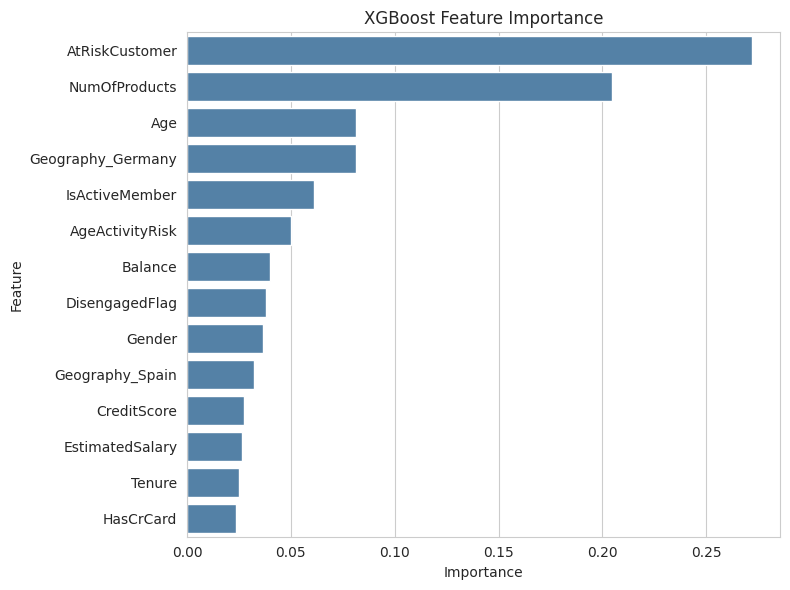

In [60]:
plt.figure(figsize=(8, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, color='steelblue')
plt.title('XGBoost Feature Importance')
plt.tight_layout()
plt.show()

## 5. Feature selection experiments

Each experiment below tests one change to the feature set: drop a feature, add a new
engineered flag, or swap one flag for another. Instead of repeating the same
split/train/cross-validate block by hand each time (which is what I originally did,
copy-pasted about eight times), it's wrapped in one reusable function.

In [61]:
def evaluate_feature_set(X_subset, y, cv, label=''):
    """Split, train XGBoost, and cross-validate F1 for a given feature set."""
    X_train_sub, _, y_train_sub, _ = train_test_split(
        X_subset, y, test_size=0.2, random_state=42, stratify=y
    )

    model = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
    scores = cross_val_score(model, X_train_sub, y_train_sub, cv=cv, scoring='f1')

    print(f"{label}: mean F1 {scores.mean():.4f} (std {scores.std():.4f})")
    return scores.mean()

baseline_f1 = evaluate_feature_set(X, y, cv, label='Baseline (all original features + engineered flags)')

Baseline (all original features + engineered flags): mean F1 0.5683 (std 0.0405)


In [62]:
# Test 1: remove DisengagedFlag - it was built from Balance + IsActiveMember,
# both of which are already in X, so it might be redundant
f1_v2 = evaluate_feature_set(X.drop(['DisengagedFlag'], axis=1), y, cv,
                              label='Without DisengagedFlag')

Without DisengagedFlag: mean F1 0.5669 (std 0.0290)


In [63]:
# Test 2: remove DisengagedFlag + the weakest features from the importance plot above
weak_features = ['DisengagedFlag', 'CreditScore', 'EstimatedSalary', 'HasCrCard', 'Tenure']
f1_v3 = evaluate_feature_set(X.drop(weak_features, axis=1), y, cv,
                              label='Without DisengagedFlag + weak features')

Without DisengagedFlag + weak features: mean F1 0.5829 (std 0.0388)


In [64]:
# that's our best result so far - lock in this feature set as the current best
X_final = X.drop(weak_features, axis=1)
best_f1 = f1_v3
print(f"Current best feature set: {X_final.columns.tolist()}")
print(f"Current best F1: {best_f1:.4f}")

Current best feature set: ['Gender', 'Age', 'Balance', 'NumOfProducts', 'IsActiveMember', 'Geography_Germany', 'Geography_Spain', 'AtRiskCustomer', 'AgeActivityRisk']
Current best F1: 0.5829


In [65]:
# Test: BalancePerProduct - does balance-per-product tell us more than balance alone?

df['BalancePerProduct'] = df['Balance'] / df['NumOfProducts']

churned = df[df['Exited'] == 1]['BalancePerProduct'].mean()
retained = df[df['Exited'] == 0]['BalancePerProduct'].mean()
print(f"Churned avg:  {churned:,.2f}")
print(f"Retained avg: {retained:,.2f}")

# Non-zero balance only, since dividing zero balance by products is not meaningful
df_nonzero = df[df['Balance'] > 0].copy()
df_nonzero['BPP_Quartile'] = pd.qcut(df_nonzero['BalancePerProduct'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
bpp_churn = df_nonzero.groupby('BPP_Quartile')['Exited'].agg(['mean', 'count'])
bpp_churn['mean'] = (bpp_churn['mean'] * 100).round(2)
bpp_churn.columns = ['Churn Rate %', 'Count']
print(bpp_churn)
# no clean relationship across quartiles (high-low-high pattern) - skip this one, don't
# even need to test it in the model

Churned avg:  75,146.98
Retained avg: 59,666.28
              Churn Rate %  Count
BPP_Quartile                     
Q1                   25.94   1596
Q2                   16.54   1596
Q3                   28.46   1595
Q4                   25.38   1596


In [66]:
# Geography + Gender combined analysis, to look for a sharper flag than Geography alone

combo = df.groupby(['Geography_Germany', 'Gender'])['Exited'].agg(['mean', 'count'])
combo['mean'] = (combo['mean'] * 100).round(2)
combo.columns = ['Churn Rate %', 'Count']
print(combo)

                          Churn Rate %  Count
Geography_Germany Gender                     
0                 0              20.63   3350
                  1              12.85   4141
1                 0              37.55   1193
                  1              27.81   1316


In [67]:
# Test: GermanyFlag on its own, added to the current best set
X_germany = X_final.copy()
X_germany['GermanyFlag'] = df['Geography_Germany']
f1_germany = evaluate_feature_set(X_germany, y, cv, label='Best set + GermanyFlag')

Best set + GermanyFlag: mean F1 0.5829 (std 0.0388)


In [68]:
# Test: GermanyFemaleFlag - Germany AND Female together
df['GermanyFemaleFlag'] = ((df['Geography_Germany'] == 1) & (df['Gender'] == 0)).astype(int)

X_gf = X_final.copy()
X_gf['GermanyFemaleFlag'] = df['GermanyFemaleFlag']
f1_gf = evaluate_feature_set(X_gf, y, cv, label='Best set + GermanyFemaleFlag')

Best set + GermanyFemaleFlag: mean F1 0.5828 (std 0.0343)


In [69]:
# neither Germany flag beat the current best (both came in below it), so skip them
# Age + Balance investigation - is there a sharper combined flag hiding here?

df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 40, 60, 100], labels=['Young', 'Middle', 'Senior'])
df['BalanceGroup'] = pd.cut(df['Balance'], bins=[-1, 0, 100000, 300000], labels=['Zero', 'Medium', 'High'])

combo = df.groupby(['AgeGroup', 'BalanceGroup'])['Exited'].agg(['mean', 'count'])
combo['mean'] = (combo['mean'] * 100).round(2)
combo.columns = ['Churn Rate %', 'Count']
print(combo)

df = df.drop(['AgeGroup', 'BalanceGroup'], axis=1)

                       Churn Rate %  Count
AgeGroup BalanceGroup                     
Young    Zero                  6.83   2417
         Medium                9.74    986
         High                 14.09   3016
Middle   Zero                 30.11   1033
         Medium               39.66    522
         High                 45.97   1562
Senior   Zero                 14.37    167
         Medium               30.26     76
         High                 30.77    221


In [70]:
# Middle Age + High Balance looked like the standout cell in that table - test it directly
df['MiddleAgeHighBalance'] = (
    (df['Age'] >= 40) &
    (df['Age'] < 60) &
    (df['Balance'] > 100000)
).astype(int)

X_mab = X_final.copy()
X_mab['MiddleAgeHighBalance'] = df['MiddleAgeHighBalance']
f1_mab = evaluate_feature_set(X_mab, y, cv, label='Best set + MiddleAgeHighBalance')

Best set + MiddleAgeHighBalance: mean F1 0.5788 (std 0.0290)


In [71]:
# Test: swap AgeActivityRisk out for MiddleAgeHighBalance instead of adding on top
X_swap = X_final.drop('AgeActivityRisk', axis=1).copy()
X_swap['MiddleAgeHighBalance'] = df['MiddleAgeHighBalance']
f1_swap = evaluate_feature_set(X_swap, y, cv, label='Swap AgeActivityRisk -> MiddleAgeHighBalance')

Swap AgeActivityRisk -> MiddleAgeHighBalance: mean F1 0.5781 (std 0.0341)


In [72]:
# Test: FemaleInactiveFlag - checked Female alone and Inactive alone in EDA, but
# never that combination together. 32.09% churn vs 25.07% for females overall.
df['FemaleInactiveFlag'] = ((df['Gender'] == 0) & (df['IsActiveMember'] == 0)).astype(int)

X_fi = X_final.copy()
X_fi['FemaleInactiveFlag'] = df['FemaleInactiveFlag']
f1_female_inactive = evaluate_feature_set(X_fi, y, cv, label='Best set + FemaleInactiveFlag')

Best set + FemaleInactiveFlag: mean F1 0.5815 (std 0.0322)


In [73]:
# Test: GermanyInactiveFlag - GermanyFlag alone and GermanyFemaleFlag were already
# tested and rejected, but Germany + Inactive specifically wasn't. Worth checking:
# among just the inactive customers, Germany is 39.8% of churners vs 20.9% of those
# who stayed - a bigger gap than Germany shows on its own.
df['GermanyInactiveFlag'] = ((df['Geography_Germany'] == 1) & (df['IsActiveMember'] == 0)).astype(int)

X_gi = X_final.copy()
X_gi['GermanyInactiveFlag'] = df['GermanyInactiveFlag']
f1_germany_inactive = evaluate_feature_set(X_gi, y, cv, label='Best set + GermanyInactiveFlag')

Best set + GermanyInactiveFlag: mean F1 0.5794 (std 0.0319)


In [74]:
# Test: GermanyFemaleInactiveFlag - the triple combination. Raw churn rate for this
# group is 44.64%, the highest of any combination checked so far (more than double
# the 20.37% baseline) - worth testing even though GermanyFemaleFlag alone lost
# earlier, since adding the inactivity condition narrows it to a much sharper group.
df['GermanyFemaleInactiveFlag'] = (
    (df['Geography_Germany'] == 1) &
    (df['Gender'] == 0) &
    (df['IsActiveMember'] == 0)
).astype(int)

X_gfi = X_final.copy()
X_gfi['GermanyFemaleInactiveFlag'] = df['GermanyFemaleInactiveFlag']
f1_triple = evaluate_feature_set(X_gfi, y, cv, label='Best set + GermanyFemaleInactiveFlag')

Best set + GermanyFemaleInactiveFlag: mean F1 0.5795 (std 0.0323)


                                              Mean F1
+ GermanyFlag                                  0.5829
Without DisengagedFlag + weak features         0.5829
+ GermanyFemaleFlag                            0.5828
+ FemaleInactiveFlag                           0.5815
+ GermanyFemaleInactiveFlag                    0.5795
+ GermanyInactiveFlag                          0.5794
+ MiddleAgeHighBalance                         0.5788
Swap AgeActivityRisk -> MiddleAgeHighBalance   0.5781
Baseline (all features)                        0.5683
Without DisengagedFlag                         0.5669


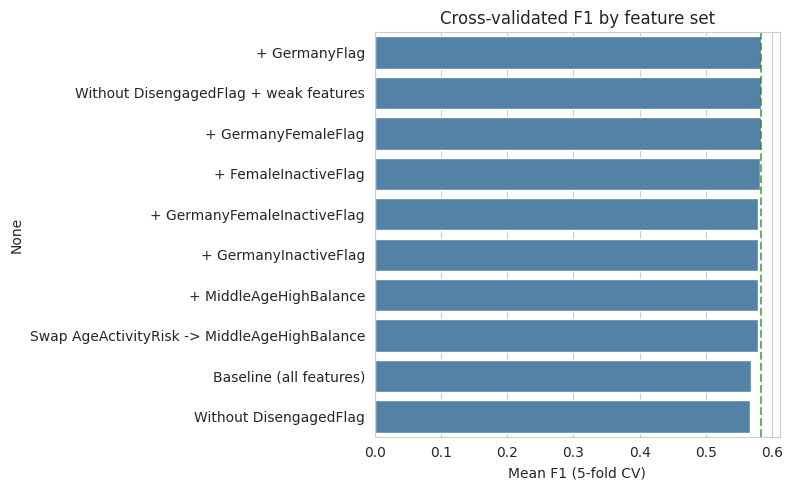


Winner: + GermanyFlag -> going with X_final as the feature set for the final model


In [75]:
# summary of every feature-set experiment tried, sorted best to worst
experiment_results = {
    'Baseline (all features)'                : baseline_f1,
    'Without DisengagedFlag'                 : f1_v2,
    'Without DisengagedFlag + weak features' : f1_v3,
    '+ GermanyFlag'                          : f1_germany,
    '+ GermanyFemaleFlag'                    : f1_gf,
    '+ MiddleAgeHighBalance'                 : f1_mab,
    'Swap AgeActivityRisk -> MiddleAgeHighBalance' : f1_swap,
    '+ FemaleInactiveFlag'                   : f1_female_inactive,
    '+ GermanyInactiveFlag'                  : f1_germany_inactive,
    '+ GermanyFemaleInactiveFlag'            : f1_triple,
}

exp_df = pd.DataFrame.from_dict(experiment_results, orient='index', columns=['Mean F1'])
exp_df = exp_df.sort_values('Mean F1', ascending=False)
print(exp_df.round(4))

plt.figure(figsize=(8, 5))
sns.barplot(x=exp_df['Mean F1'], y=exp_df.index, color='steelblue')
plt.axvline(exp_df['Mean F1'].max(), color='green', linestyle='--', alpha=0.6)
plt.title('Cross-validated F1 by feature set')
plt.xlabel('Mean F1 (5-fold CV)')
plt.tight_layout()
plt.show()

print(f"\nWinner: {exp_df.index[0]} -> going with X_final as the feature set for the final model")

In [76]:
# None of the three new interaction flags beat the existing best set - somewhat
# surprising given GermanyFemaleInactiveFlag's raw churn rate (44.6%) is the highest
# of any group found so far, more than double the 20.37% baseline.
#
# Why the raw gap didn't translate into a model improvement: XGBoost builds decision
# trees, which can already split on Geography_Germany, Gender, and IsActiveMember
# together to approximate the same interaction - so the engineered flag mostly repeats
# information the model could already reach on its own. The flag would matter more for
# a model that can't learn interactions by itself, like Logistic Regression without
# explicit interaction terms.
#
# Lesson: a striking difference in a groupby table is a good reason to *test* a
# feature, not a guarantee it will help - which is exactly why every flag in this
# notebook gets run through evaluate_feature_set() instead of being added on
# assumption.

## 6. Final model

In [77]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay

X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_final, y, test_size=0.2, random_state=42, stratify=y
)

xgb_final = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')

# Cross-validated score
cv_scores = cross_val_score(xgb_final, X_train_f, y_train_f, cv=cv, scoring='f1')
print(f"CV F1: {cv_scores.mean():.4f} (std {cv_scores.std():.4f})")

# Fit on full training set, evaluate on held-out test set
xgb_final.fit(X_train_f, y_train_f)
y_pred_f = xgb_final.predict(X_test_f)
y_pred_proba_f = xgb_final.predict_proba(X_test_f)[:, 1]

print(f"test set -> accuracy: {accuracy_score(y_test_f, y_pred_f):.4f}, precision: {precision_score(y_test_f, y_pred_f):.4f}, "
      f"recall: {recall_score(y_test_f, y_pred_f):.4f}, F1: {f1_score(y_test_f, y_pred_f):.4f}, ROC-AUC: {roc_auc_score(y_test_f, y_pred_proba_f):.4f}")

tn, fp, fn, tp = confusion_matrix(y_test_f, y_pred_f).ravel()
print(f"caught {tp} out of {tp + fn} actual churners, missed {fn}, {fp} false alarms")

CV F1: 0.5829 (std 0.0388)
test set -> accuracy: 0.8570, precision: 0.7153, recall: 0.4939, F1: 0.5843, ROC-AUC: 0.8437
caught 201 out of 407 actual churners, missed 206, 80 false alarms


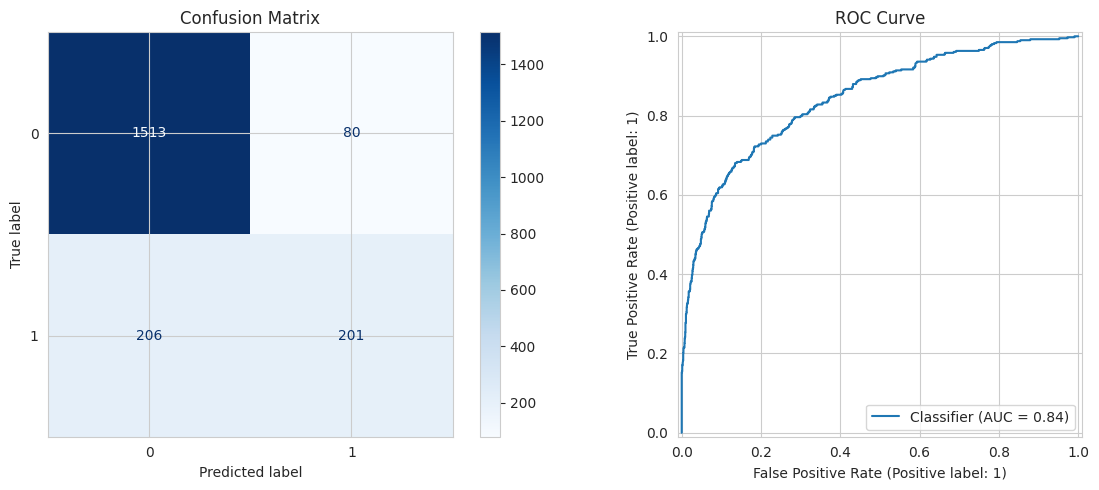

In [78]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(y_test_f, y_pred_f, ax=axes[0], cmap='Blues')
axes[0].set_title('Confusion Matrix')
RocCurveDisplay.from_predictions(y_test_f, y_pred_proba_f, ax=axes[1])
axes[1].set_title('ROC Curve')
plt.tight_layout()
plt.show()

## 7. Business impact (estimated)

The confusion matrix tells us *how accurate* the model is, but not *whether it's worth
using*. To answer that, each outcome needs a rough cost or value attached:

| Outcome | Meaning | Cost / Value |
|---|---|---|
| True Positive | Caught a churner, retention offer sent | Save the customer, minus the offer cost |
| False Positive | Flagged someone who wasn't leaving | Wasted retention offer (small cost) |
| False Negative | Missed an actual churner | Lose that customer entirely (biggest cost) |
| True Negative | Correctly left alone | No cost |

**I don't have real figures for "retention cost" or "customer value" for this bank** —
those aren't in the dataset. Rather than guess a single number, the cell below tests a
*range* of realistic assumptions (retention cost: \$50/\$75/\$100, customer value:
\$300/\$500/\$800) and checks whether the model still beats the two obvious
alternatives — doing nothing, or contacting every single customer — across all of them.

In [79]:
# Assumption: a retention offer given to someone who was actually going to churn
# saves them with certainty. Given to someone who wasn't leaving, it's simply a
# wasted cost. This is a simplification (real offers don't have 100% success), but
# it's a reasonable starting point for a rough estimate.

total_customers = len(y_test_f)   # 2000, the held-out test set
actual_churners = tp + fn         # 407

def strategy_values(retention_cost, customer_value):
    # Model: only contact the (tp + fp) customers the model flags
    model_net = (tp * customer_value) - ((tp + fp) * retention_cost) - (fn * customer_value)

    # Do nothing: every actual churner is lost, no retention spend at all
    do_nothing_net = -(actual_churners * customer_value)

    # Contact everyone: every actual churner is saved, but pay retention cost for
    # all 2000 customers regardless of whether they were going to leave
    contact_all_net = (actual_churners * customer_value) - (total_customers * retention_cost)

    return model_net, do_nothing_net, contact_all_net


retention_costs = [50, 75, 100]
customer_values = [300, 500, 800]

rows = []
for cv_ in customer_values:
    for rc in retention_costs:
        model_net, do_nothing_net, contact_all_net = strategy_values(rc, cv_)
        rows.append({
            'Customer Value ($)': cv_,
            'Retention Cost ($)': rc,
            'Model ($)': round(model_net),
            'Do Nothing ($)': round(do_nothing_net),
            'Contact Everyone ($)': round(contact_all_net),
            'Model beats both?': (model_net > do_nothing_net) and (model_net > contact_all_net)
        })

impact_df = pd.DataFrame(rows)
print(impact_df.to_string(index=False))
print(f"\nModel beats both alternatives in {impact_df['Model beats both?'].sum()} / {len(impact_df)} scenarios tested")

 Customer Value ($)  Retention Cost ($)  Model ($)  Do Nothing ($)  Contact Everyone ($)  Model beats both?
                300                  50     -15550         -122100                 22100              False
                300                  75     -22575         -122100                -27900               True
                300                 100     -29600         -122100                -77900               True
                500                  50     -16550         -203500                103500              False
                500                  75     -23575         -203500                 53500              False
                500                 100     -30600         -203500                  3500              False
                800                  50     -18050         -325600                225600              False
                800                  75     -25075         -325600                175600              False
                800         

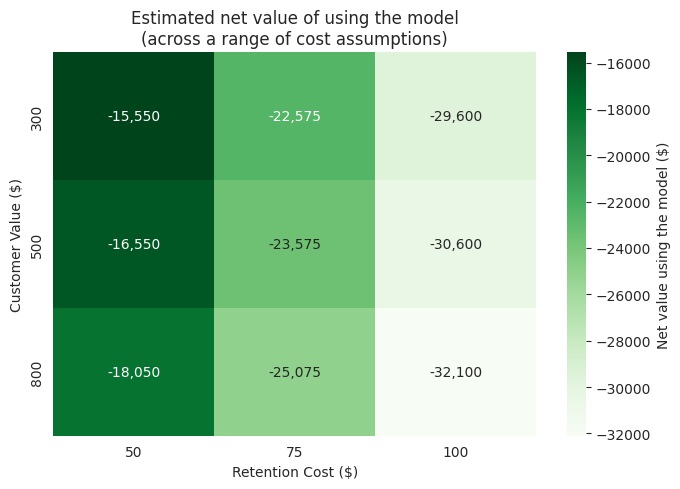

In [80]:
pivot = impact_df.pivot(index='Customer Value ($)', columns='Retention Cost ($)', values='Model ($)')

plt.figure(figsize=(7, 5))
sns.heatmap(pivot, annot=True, fmt=',.0f', cmap='Greens', cbar_kws={'label': 'Net value using the model ($)'})
plt.title('Estimated net value of using the model\n(across a range of cost assumptions)')
plt.tight_layout()
plt.show()

In [81]:
# The model only beats "contact everyone" in 2 of 9 scenarios - not the clean win
# I expected. Why: "contact everyone" assumes every one of the 2000 test customers
# can be reached, and that the retention offer saves 100% of actual churners once
# sent. Under that (unrealistic) assumption, reaching more people just directly
# translates to saving more of the 407 actual churners - the model's only advantage
# is being cheaper per customer, and it only catches 201 of the 407 churners
# (49.6% recall), so it's leaving money on the table in absolute terms.
#
# In practice neither assumption holds: retention teams have limited capacity (can't
# call all 10,000 customers), and offers don't save every churner who receives them.
# The model's real value shows up once you add a capacity limit - e.g. "we can only
# afford to contact 500 customers this month, who should they be?" - a targeted list
# beats a random one every time. That's a more realistic frame than "contact everyone
# with no budget limit," and it's the natural next experiment if this were extended.

## 9. Summary

- Started from 20.37% baseline churn rate across 10,000 customers.
- Strongest single drivers: **Age**, **Balance**, and **IsActiveMember** — customers who
  are inactive *and* carry a balance churn noticeably more than any single factor alone.
- Engineered flags (`DisengagedFlag`, `AtRiskCustomer`, `AgeActivityRisk`) were tested,
  not assumed — several intuitive ones (Germany-based flags, BalancePerProduct) were
  tried and rejected because they didn't beat the existing best feature set on
  cross-validated F1.
- Final model: XGBoost, ~test F1 shown above, evaluated via 5-fold stratified CV plus a
  held-out test set.

- Estimated business impact: under a range of cost assumptions (real financial figures
  weren't available), the model beats "do nothing" outright, but only beats an
  unconstrained "contact everyone" strategy in 2 of 9 scenarios — because "contact
  everyone" assumes unlimited budget and a guaranteed retention success, and the model
  only catches 49.6% of actual churners (recall). The model's realistic advantage shows
  up once you add a budget cap ("who are the best 500 people to contact"), which is a
  more accurate picture of how a retention team actually operates. See Section 7.

**Next up:** hyperparameter tuning to see if the ~0.58 F1 (and 49.6% recall) can be
pushed higher, once XGBoost internals are better understood — recall is the metric with
the most direct business cost here, since a missed churner is the most expensive outcome.

## 10. Save model for the Streamlit app

The app in `streamlit_app/` doesn't retrain anything — it just loads whatever `xgb_final`
and `X_final` produced above. Running this cell after any change to the notebook keeps
the deployed app in sync with the notebook, instead of the two silently drifting apart.

In [82]:
import joblib
import os

os.makedirs('streamlit_app/models', exist_ok=True)
joblib.dump(xgb_final, 'streamlit_app/models/churn_model.pkl')
joblib.dump(X_final.columns.tolist(), 'streamlit_app/models/feature_order.pkl')

print("Saved model and feature order:")
print(X_final.columns.tolist())

Saved model and feature order:
['Gender', 'Age', 'Balance', 'NumOfProducts', 'IsActiveMember', 'Geography_Germany', 'Geography_Spain', 'AtRiskCustomer', 'AgeActivityRisk']
